## CNN
The MNIST dataset is a large collection of handwritten digits. It’s widely regarded as a benchmark dataset for evaluating the performance of various image classification algorithms. The dataset contains 70,000 grayscale images of handwritten digits (0 to 9), with each image having a size of 28x28 pixels. The pixel values range from 0 to 255, where 0 represents black, 255 represents white, and the values in between represent various shades of gray.

In [12]:
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [13]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [14]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
sample_set = x_train[0]

In [5]:
def calculate_target(img_shape, kernel_shape):
    row_size = img_shape[0] - kernel_shape[0] + 1
    col_size = img_shape[1] - kernel_shape[1] + 1
    if len(kernel_shape) == 3:
        feature_size = kernel_shape[2]
    else:
        feature_size = 1
    target = np.zeros((row_size , col_size, feature_size))
    
    return row_size, col_size, feature_size, target

def convolve(img, kernel):
    row_size, col_size, feature_size, CovImage = calculate_target(
        img.shape,
        kernel.shape
    )
    if feature_size == 1:
        kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
        CovImage = CovImage.reshape(CovImage.shape[0], CovImage.shape[1], 1)
    for k in range(feature_size):
        for i in range(row_size):
            for j in range(col_size):
                CovImage[i,j,k] = (img[i:i+kernel.shape[0],j:j+kernel.shape[1]] * kernel[:, :, k]).sum()

    return CovImage


In [6]:
kersl = np.array([[0, 0, 0],
                   [0, 0, 1],
                   [0, 0, 0]])


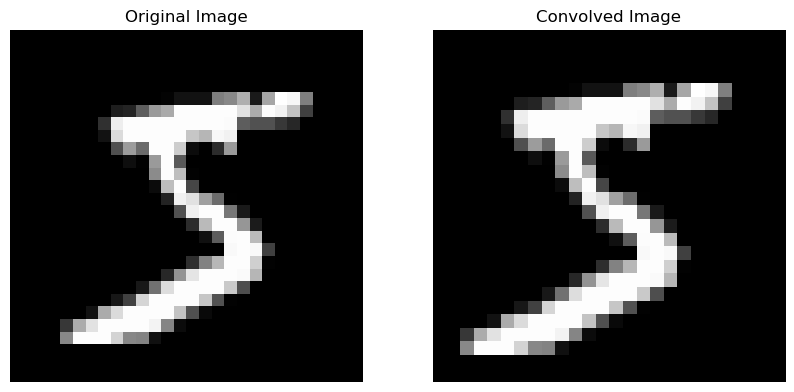

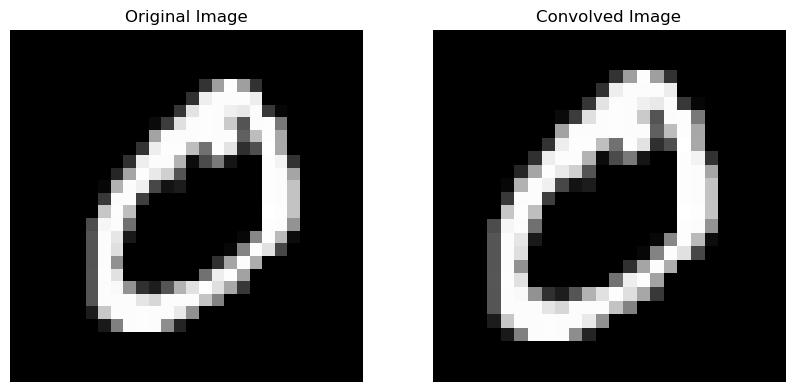

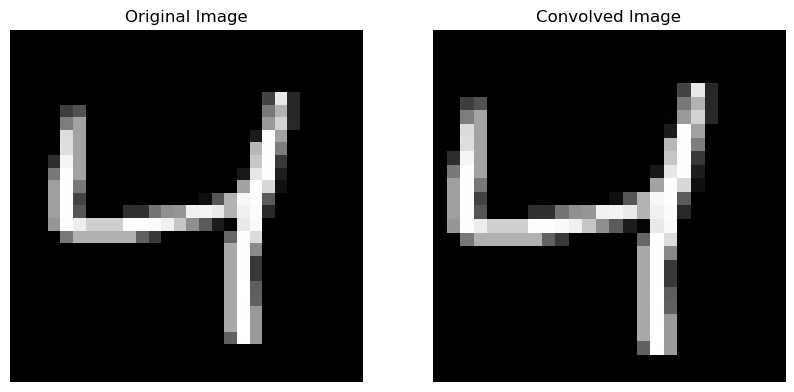

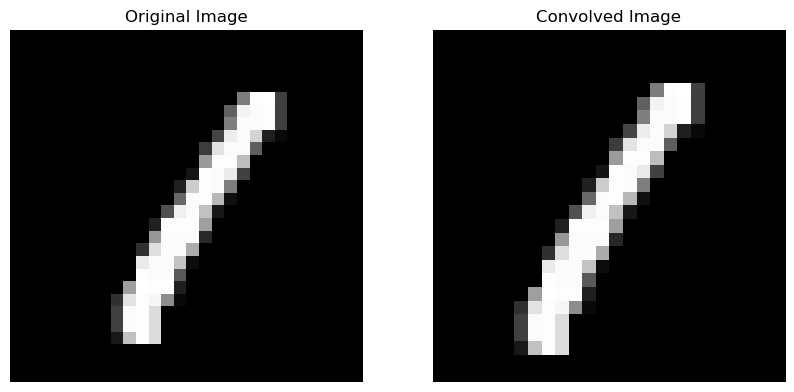

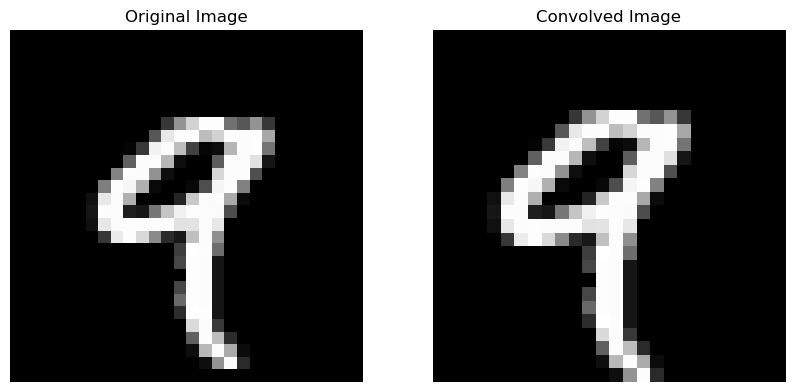

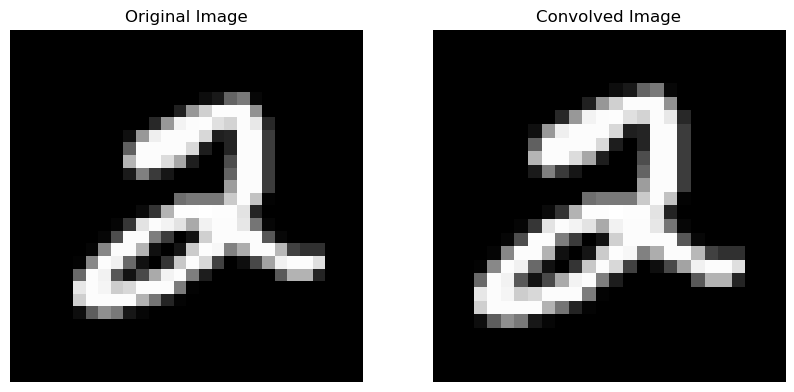

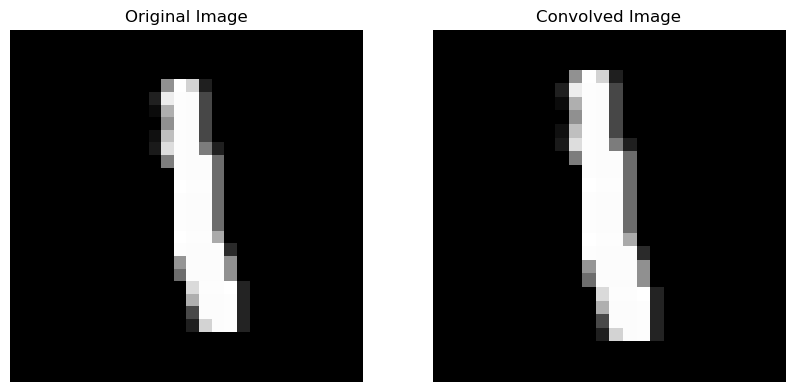

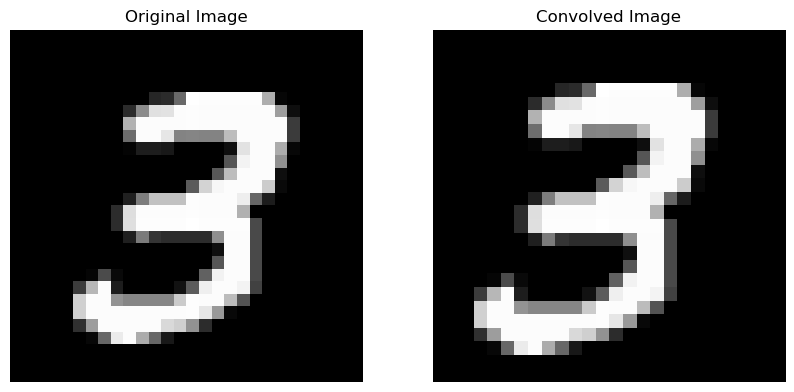

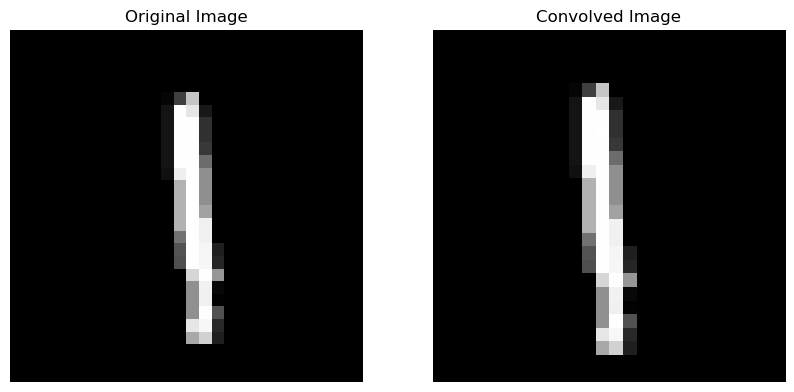

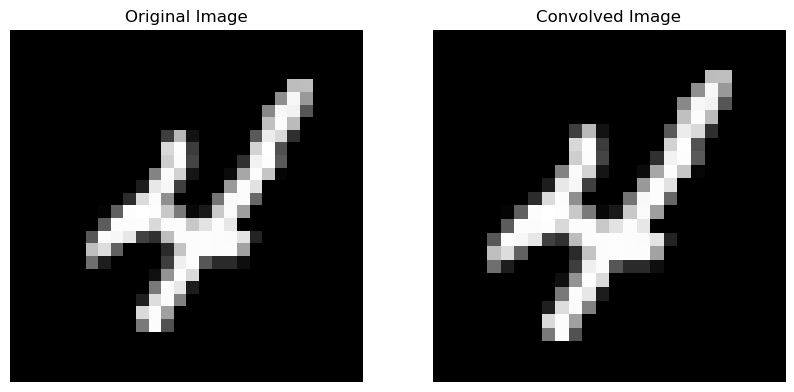

In [7]:
## compare show
for _ in x_train[:10]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(_, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    convolved_image = convolve(_, kersl)
    
    plt.subplot(1, 2, 2)
    plt.imshow(convolved_image, cmap='gray')
    plt.title('Convolved Image')
    plt.axis('off')

    plt.show()

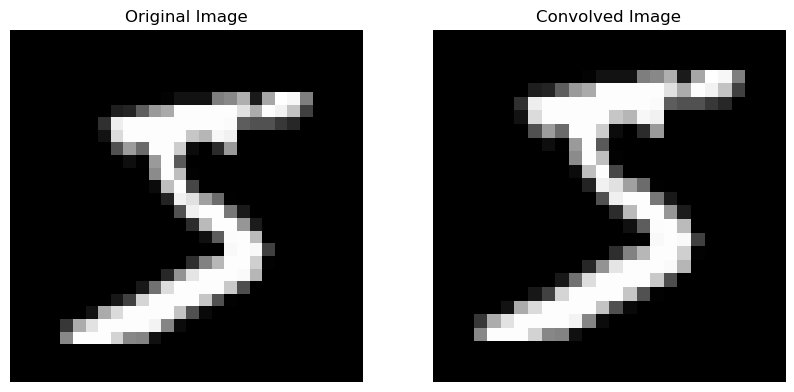

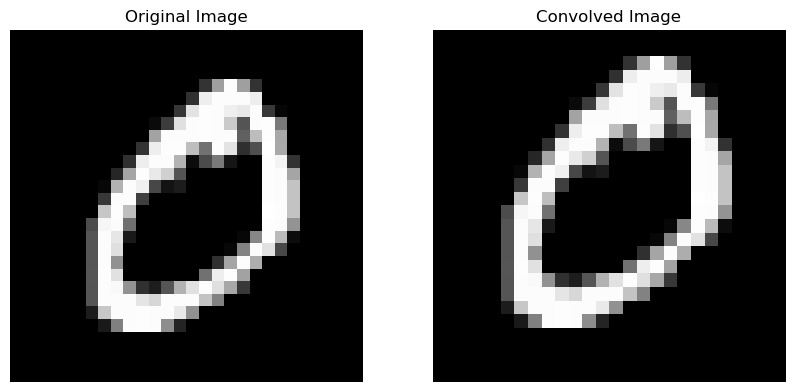

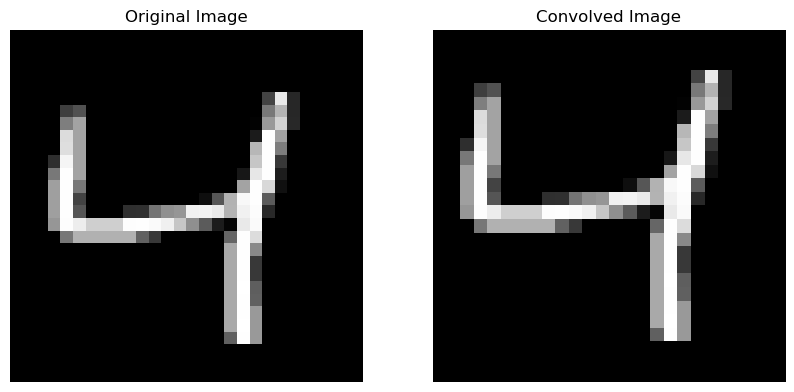

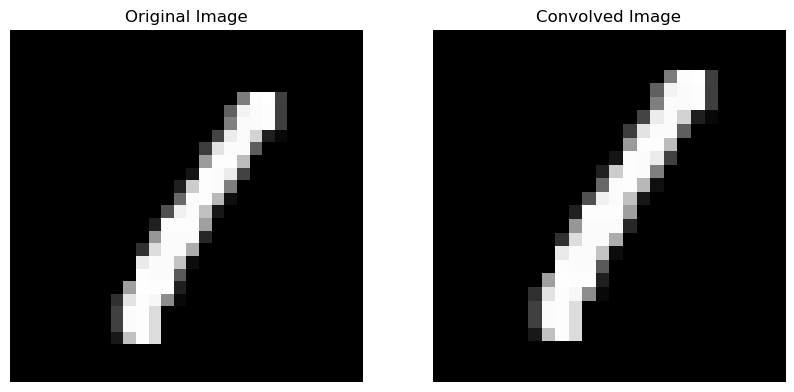

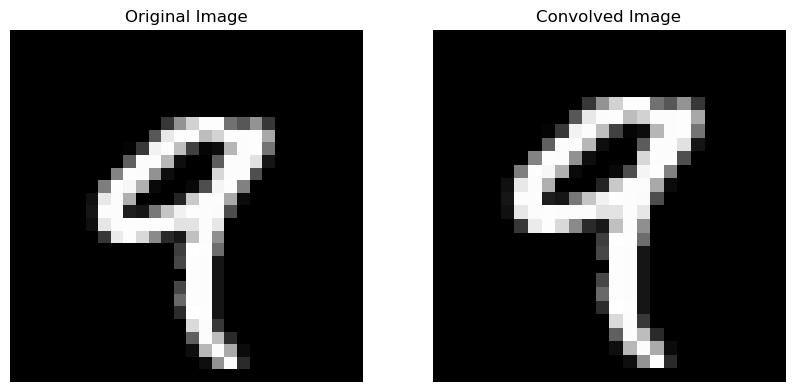

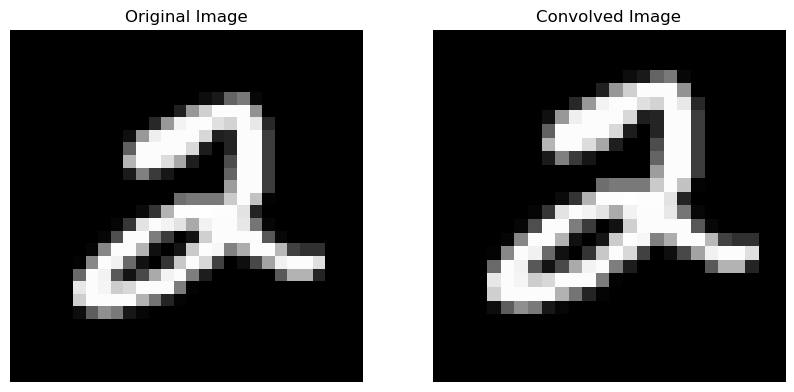

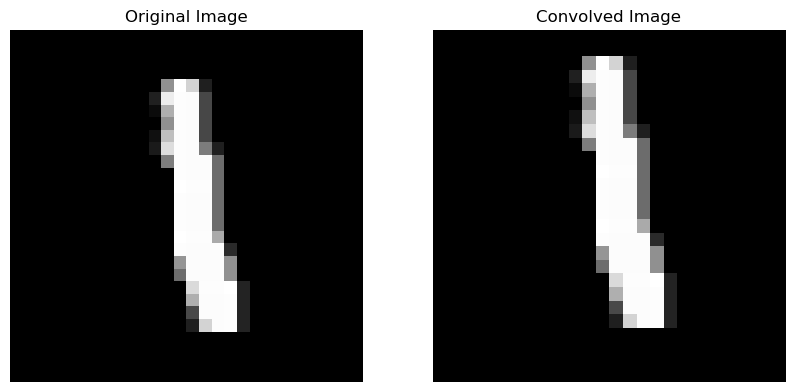

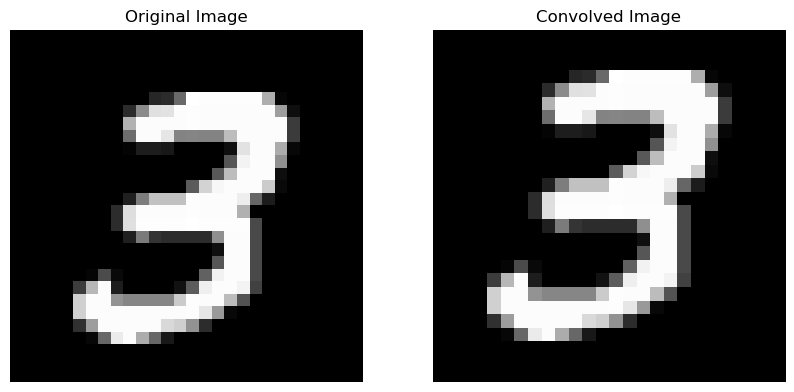

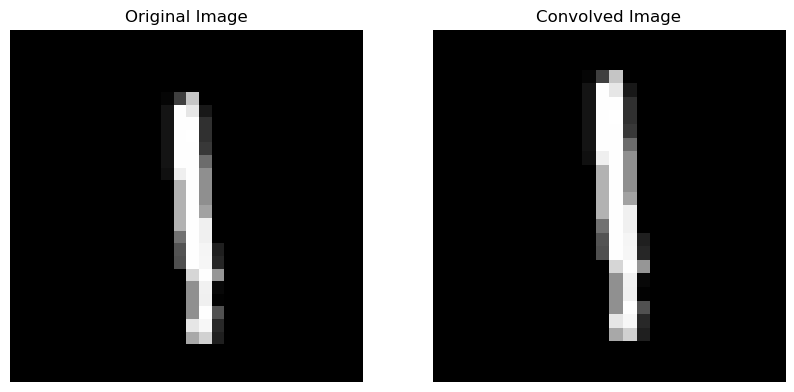

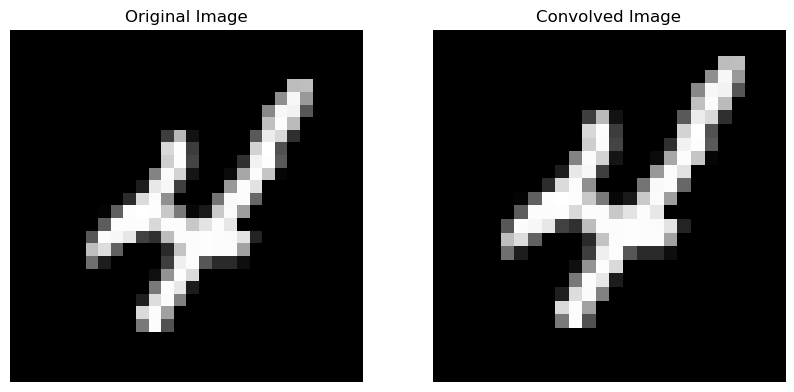

In [8]:
kerst = np.array([[0, 0, 0],
                   [0, 0, 0],
                   [0, 1, 0]])
## compare show
for _ in x_train[:10]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(_, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    convolved_image = convolve(_, kerst)
    
    plt.subplot(1, 2, 2)
    plt.imshow(convolved_image, cmap='gray')
    plt.title('Convolved Image')
    plt.axis('off')

    plt.show()

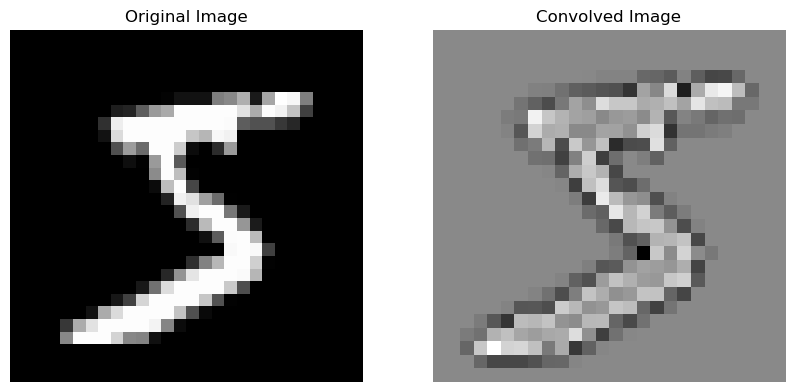

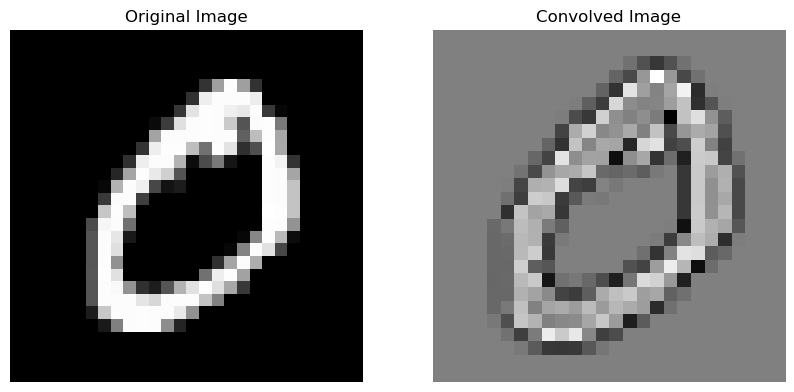

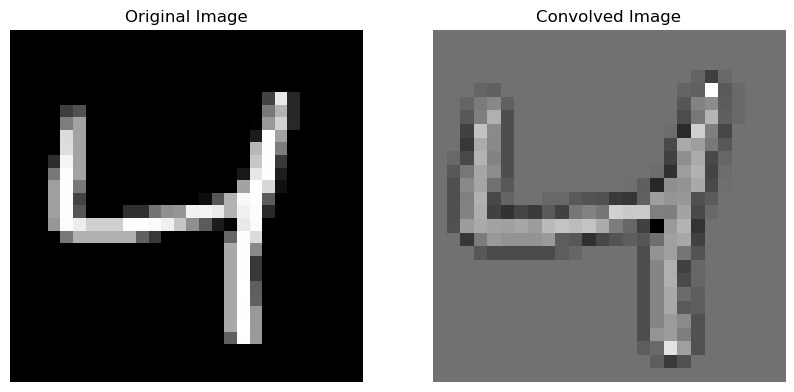

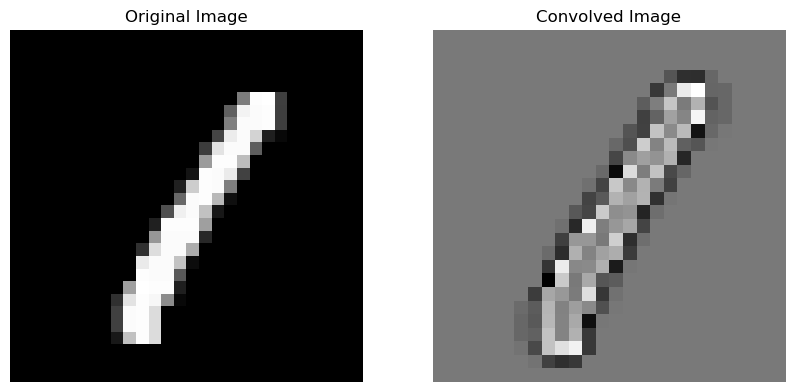

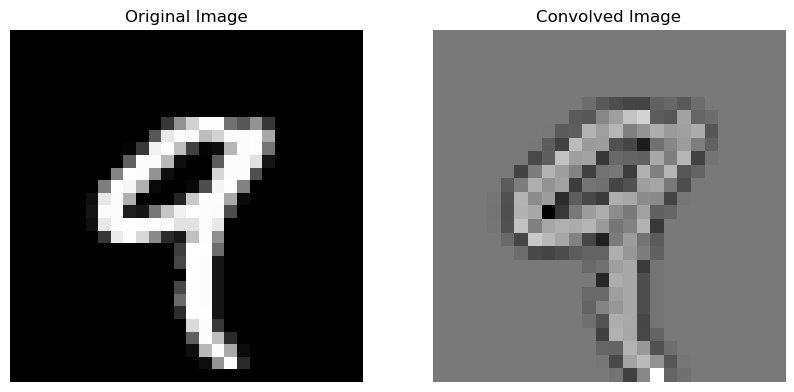

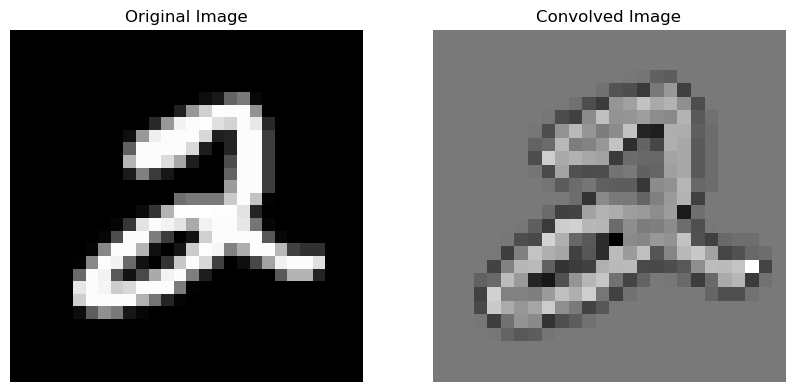

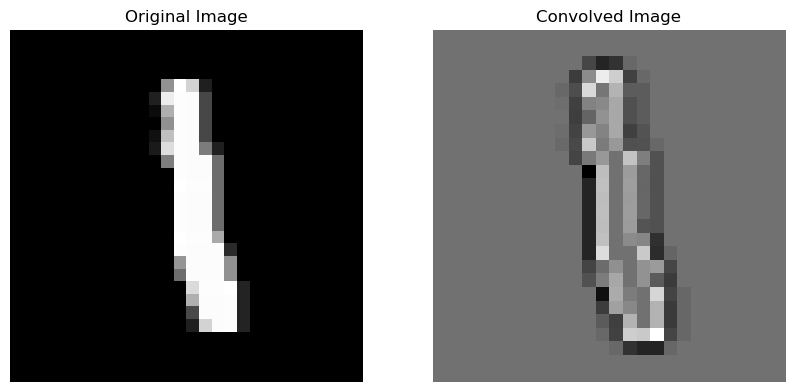

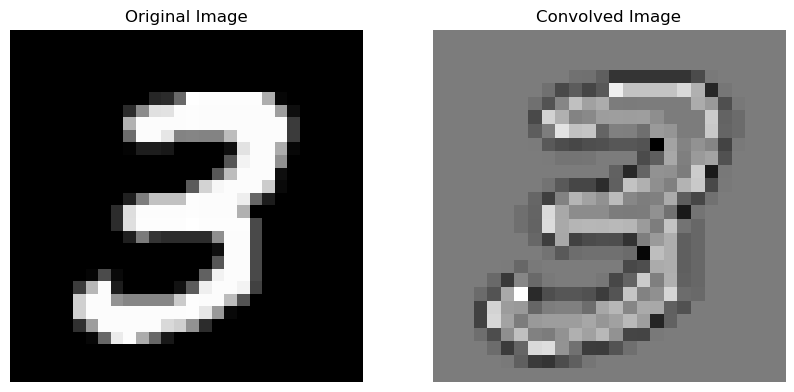

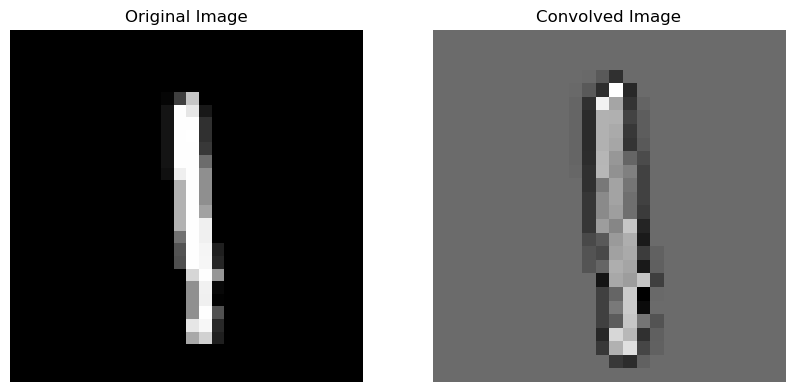

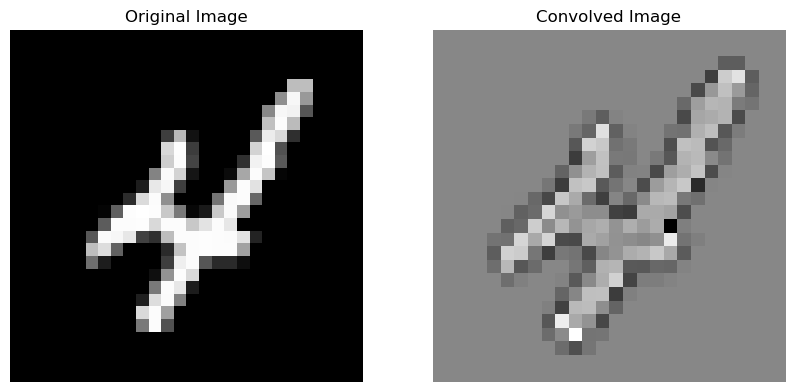

In [9]:
kerlap = np.array([[0, -2, 0],
                   [-2, 8, -2],
                   [0, -2, 0]])/2
for _ in x_train[:10]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(_, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    convolved_image = convolve(_, kerlap)
    
    plt.subplot(1, 2, 2)
    plt.imshow(convolved_image, cmap='gray')
    plt.title('Convolved Image')
    plt.axis('off')

    plt.show()

### Tensorflow version


Using Tensorflow to fit a CNN which performs 10 class classification, using the images in x_train to predict y_train and evaluate performace on the test data. 

In [10]:
## Define the ResNet
def resblock(x, filters, kernel_size):
    shortcut = x
    x = tf.keras.layers.Conv2D(filters, (kernel_size, kernel_size), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(filters, (kernel_size, kernel_size), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x


In [11]:
## build a model with 2 hidden layers with cov2d
inputs = tf.keras.Input(shape = (28, 28))
x = tf.keras.layers.Reshape((28, 28, 1))(inputs)
x = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)

In [12]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt, 
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])
model.fit(x_train, y_train, batch_size=32, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9569 - loss: 0.2444 - val_accuracy: 0.9784 - val_loss: 0.1145
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9821 - loss: 0.0817 - val_accuracy: 0.9851 - val_loss: 0.0650
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9856 - loss: 0.0546 - val_accuracy: 0.9880 - val_loss: 0.0429
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9885 - loss: 0.0386 - val_accuracy: 0.9837 - val_loss: 0.0516
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9901 - loss: 0.0332 - val_accuracy: 0.9875 - val_loss: 0.0418
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9911 - loss: 0.0281 - val_accuracy: 0.9884 - val_loss: 0.0435
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9927 - loss: 0.0238 - val_accuracy: 0.9881 - val_loss: 0.0483
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9930 -

In [13]:
fit_sample = tf.keras.Sequential([
    tf.keras.Input(shape = (28, 28)),
    tf.keras.layers.Reshape((28, 28, 1)),
    tf.keras.layers.Conv2D(8, (3, 3), padding='same'), ## numbers of filters is 8
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(8),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
fit_sample.compile(optimizer=opt, 
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])
fit_sample.fit(x_train, y_train, batch_size=32, epochs=2, validation_data=(x_test, y_test))

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8931 - loss: 0.3406 - val_accuracy: 0.9650 - val_loss: 0.1167
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9681 - loss: 0.1071 - val_accuracy: 0.9623 - val_loss: 0.1197


* The samplist model we get is just one hidden layer
* With Batch Norm and Maxpooling
* The accuracy for test data is 96%

In [14]:
conv_weight = tf.squeeze(model.layers[2].get_weights()[0],axis=2)

In [15]:
conv_weight_arr = conv_weight.numpy()

In [16]:
row_size, col_size, feature_size, CovImage = calculate_target(x_train[0].shape, conv_weight_arr.shape)

In [17]:
feature_maps = np.zeros((row_size, col_size, feature_size))
for k in range(feature_size):
    feature_maps[:,:,k] = convolve(x_train[0], conv_weight_arr[:,:,k]).squeeze(axis=2)

The weights convoluted the image into 32 feature maps

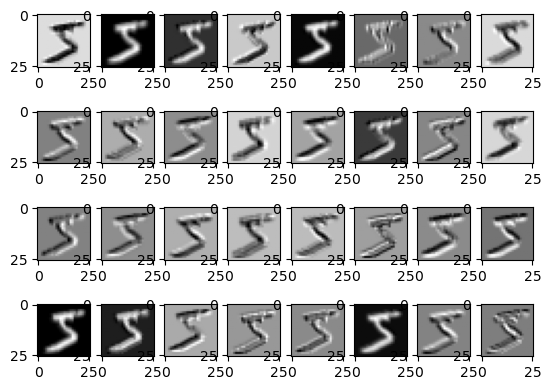

In [18]:
for i in range(feature_size):
    plt.subplot(4, 8, i + 1)
    plt.imshow(feature_maps[:,:,i], cmap='gray')

In [19]:
layer_outputs = [layer.output for layer in fit_sample.layers]
layers_model = tf.keras.Model(inputs=fit_sample.inputs, outputs = layer_outputs)

layers_activated_outputs = layers_model.predict(x_test[1:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [20]:
## the dimension of every layer
for layer, output in zip(fit_sample.layers,layers_activated_outputs):
    print(f"Layer Name: {layer.name:<25} | Output Shape: {output.shape}")

Layer Name: reshape_1                 | Output Shape: (1, 28, 28, 1)
Layer Name: conv2d_2                  | Output Shape: (1, 28, 28, 8)
Layer Name: activation_2              | Output Shape: (1, 28, 28, 8)
Layer Name: batch_normalization_2     | Output Shape: (1, 28, 28, 8)
Layer Name: max_pooling2d_2           | Output Shape: (1, 14, 14, 8)
Layer Name: flatten_1                 | Output Shape: (1, 1568)
Layer Name: dense_2                   | Output Shape: (1, 8)
Layer Name: activation_3              | Output Shape: (1, 8)
Layer Name: dense_3                   | Output Shape: (1, 10)


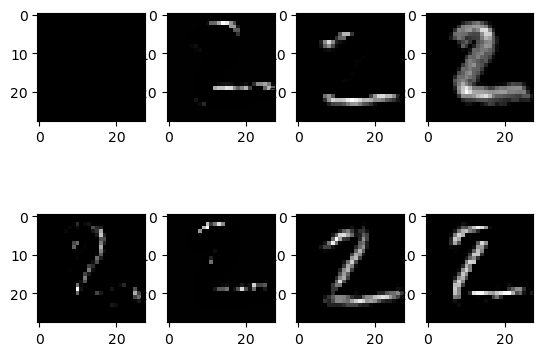

In [21]:
# #conv2d layer
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(layers_activated_outputs[2][0,:,:,i], cmap='gray')
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(layers_activated_outputs[3][0,:,:,i], cmap = 'gray')


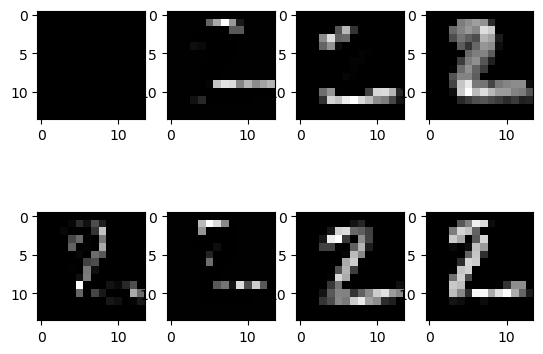

In [22]:
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(layers_activated_outputs[4][0,:,:,i], cmap = 'gray')


### Using torch

In [1]:
import numpy as np
import torch
import torch.functional as F
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [4]:
batch_size = 64
num_epochs = 10
learning_rate = 0.01

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [35]:
train_dataset = datasets.MNIST(
    root='.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root='.', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle = True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle = False)

In [46]:
## Define the Neural Network
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv2d = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)
        self.relu = nn.ReLU()
        self.bn = nn.BatchNorm2d(8)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc2 = nn.Linear(8*13*13, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.conv2d(x)
        x = self.relu(x)
        x = self.bn(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [55]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
torch_model = MNISTNet()
torch_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(torch_model.parameters(), lr = learning_rate)

In [58]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)

def train(model, device, train_loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for i,(inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy(outputs, labels)

        if (i + 1) % 200 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 200:.4f}, Accuracy: {running_acc / 200:.4f}')
            running_loss = 0.0
            running_acc = 0.0

def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            test_acc += accuracy(outputs, labels)
    print(f'Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {test_acc / len(test_loader):.4f}')

Epoch [2/10], Step [200/938], Loss: 0.0208, Accuracy: 0.9949
Epoch [2/10], Step [400/938], Loss: 0.0332, Accuracy: 0.9927
Epoch [2/10], Step [600/938], Loss: 0.0419, Accuracy: 0.9909
Epoch [2/10], Step [800/938], Loss: 0.0340, Accuracy: 0.9910
Test Loss: 0.1229, Test Accuracy: 0.9824
Epoch [3/10], Step [200/938], Loss: 0.0162, Accuracy: 0.9950
Epoch [3/10], Step [400/938], Loss: 0.0383, Accuracy: 0.9924
Epoch [3/10], Step [600/938], Loss: 0.0285, Accuracy: 0.9925
Epoch [3/10], Step [800/938], Loss: 0.0336, Accuracy: 0.9913
Test Loss: 0.1081, Test Accuracy: 0.9834
Epoch [4/10], Step [200/938], Loss: 0.0192, Accuracy: 0.9952
Epoch [4/10], Step [400/938], Loss: 0.0346, Accuracy: 0.9929
Epoch [4/10], Step [600/938], Loss: 0.0506, Accuracy: 0.9908
Epoch [4/10], Step [800/938], Loss: 0.0399, Accuracy: 0.9923
Test Loss: 0.1092, Test Accuracy: 0.9842
Epoch [5/10], Step [200/938], Loss: 0.0218, Accuracy: 0.9948
Epoch [5/10], Step [400/938], Loss: 0.0304, Accuracy: 0.9935
Epoch [5/10], Step [600

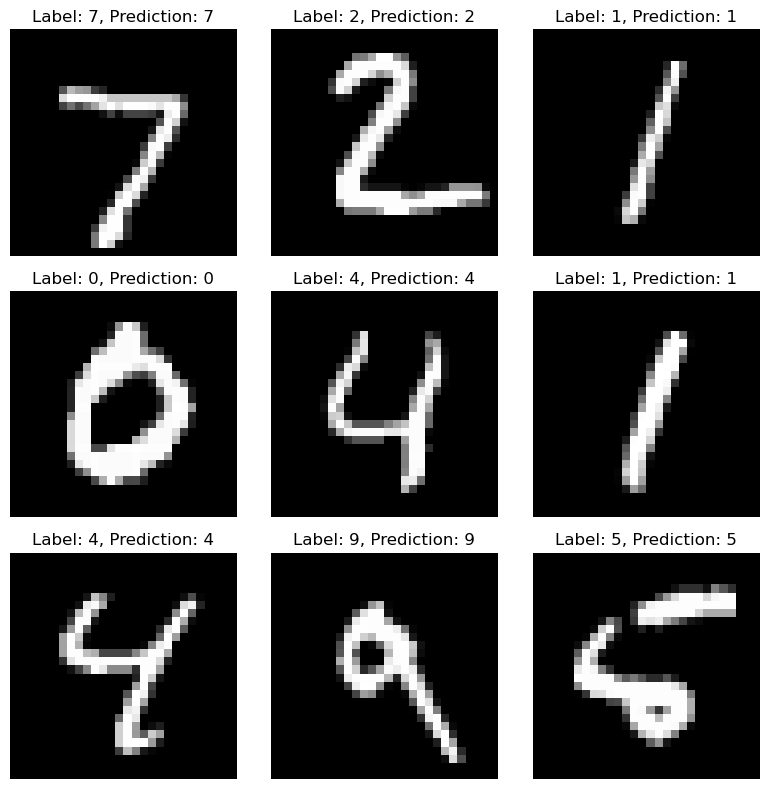

In [61]:
for epoch in range(1, num_epochs + 1):
    train(torch_model, device, train_loader, criterion, optimizer, epoch)
    test(torch_model, device, test_loader, criterion)

samples, labels = next(iter(test_loader))
samples = samples.to(device)
outputs = torch_model(samples)
_, preds = torch.max(outputs, 1)

samples = samples.cpu().numpy()
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(samples[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i]}, Prediction: {preds[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()